In [94]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import crystalball

np.random.seed(1234)

## Aim of this exercise
1. Understand the idea of CIs using Neyman construction
2. Check the CIs for Symmetric response, tail on one side and (3) wider distribution on one side with double sided gaussian
3. What do you notice in all the 3 cases?
4. What coverage do you see?


In [131]:
m_true = 125.0
#response = "gaus"
#response = "cb"
response = "dcb"

In [132]:
### Gaussian detector response
def gaussian_response(mtrue, sigma, N):
    return np.random.normal(mtrue, sigma, N)

In [133]:
### Crystal Ball detector response
def crystalball_response(mtrue, sigma, alpha=1.5, n=3, N=100):

    x = crystalball.rvs(beta=alpha,
                        m=n,
                        loc=mtrue,
                        scale=sigma,
                        size=N)

    return x

In [134]:
### Two sided asymmetric gaussian
def cruijff_response(mtrue,
                     sigmaL,
                     sigmaR,
                     N):

    x = np.random.randn(N)

    reco = np.empty(N)

    mask = x<0

    reco[mask] = mtrue + sigmaL*x[mask]

    reco[~mask] = mtrue + sigmaR*x[~mask]

    return reco

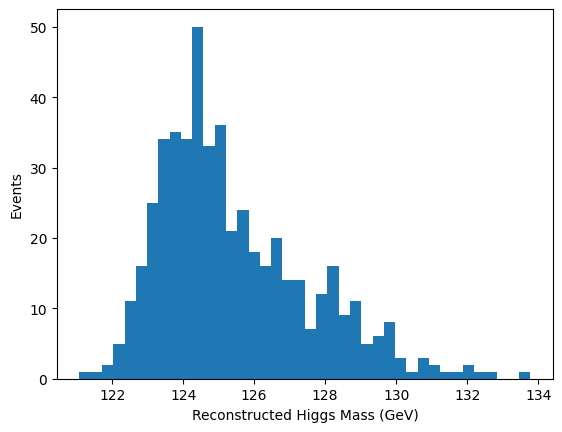

In [135]:
### Generate one pseudo experiment
Nevents = 500

sigma_detector = 1.3

reco = gaussian_response(m_true,
                         sigma_detector,
                         Nevents)

if response=="cb":
        reco = crystalball_response(m_true,sigma_detector,1.5,3,Nevents)
        
if response=="dcb":
        reco = cruijff_response(m_true,sigma_detector, sigma_detector*2, Nevents )
        
plt.hist(reco,bins=40)

plt.xlabel("Reconstructed Higgs Mass (GeV)")
plt.ylabel("Events")
plt.show()

In [136]:
### define estimator of mass
def estimate_mass(data):
    return np.mean(data)

In [137]:
mhat = estimate_mass(reco)

#print(f'reco is {reco} and mhat is {mhat}')

In [138]:
### Generate many pseudoexperiments.
Ntoys = 5000

estimates = []

reco = gaussian_response(m_true,
                             sigma_detector,
                             Nevents)

    
if response=="cb":
    reco = crystalball_response(m_true,sigma_detector,1.5,3,Nevents)
        
if response=="dcb":
    reco = cruijff_response(m_true,sigma_detector, sigma_detector*2, Nevents )
        

estimates = reco


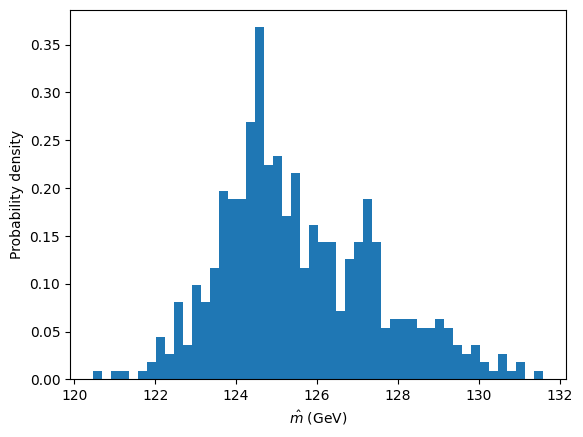

In [139]:
### plot
plt.hist(estimates,
         bins=50,
         density=True)

plt.xlabel(r'$\hat{m}$ (GeV)')
plt.ylabel("Probability density")
plt.show()

In [140]:
### classical CI
low68 = np.percentile(estimates,16)

high68 = np.percentile(estimates,84)

print(low68,high68)

123.7870796502335 127.4687660405189


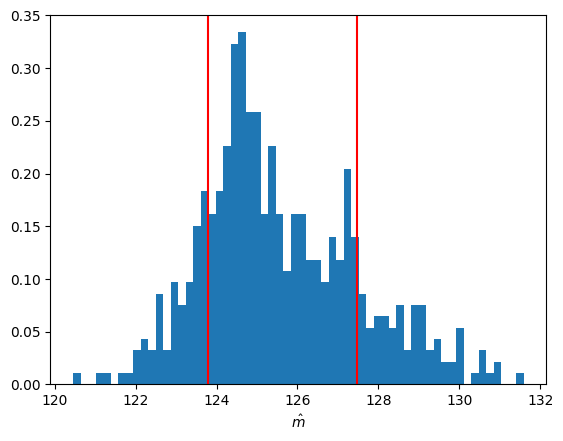

In [141]:
### plot
plt.hist(estimates,
         bins=60,
         density=True)

plt.axvline(low68,color='red')

plt.axvline(high68,color='red')

plt.xlabel(r'$\hat{m}$')
plt.show()

In [142]:
#build Neyman belt

## extend 10*sigma on each side to catch power-law tails
belt_margin = 10 * sigma_detector
trueMasses = np.arange(m_true - belt_margin,
                        m_true + belt_margin + 0.01,
                        0.01)

print(f"Belt covers [{trueMasses.min():.1f}, {trueMasses.max():.1f}] GeV")

Belt covers [112.0, 138.0] GeV


In [143]:
lower=[]

upper=[]

In [144]:
# Belt construction: sample the distribution of the estimator
# at each true mass value.
# The estimator here is a single measurement (mhat = reco[0]),
# so we sample many single measurements from the response function.

Ntoys_belt = 10000   # single measurements per belt point

for mt in trueMasses:

    estimates=[]
    
    reco = gaussian_response(mt,
                            sigma_detector,
                            Ntoys_belt)

    if response=="cb":
        reco = crystalball_response(mt,sigma_detector,1.5,3,Ntoys_belt)
        
    if response=="dcb":
        reco = cruijff_response(mt,sigma_detector, sigma_detector*2, Ntoys_belt)
        
    estimates = reco

    estimates=np.array(estimates)

    lower.append(
        np.percentile(estimates,16)
    )

    upper.append(
        np.percentile(estimates,84)
    )

lower = np.array(lower)
upper = np.array(upper)

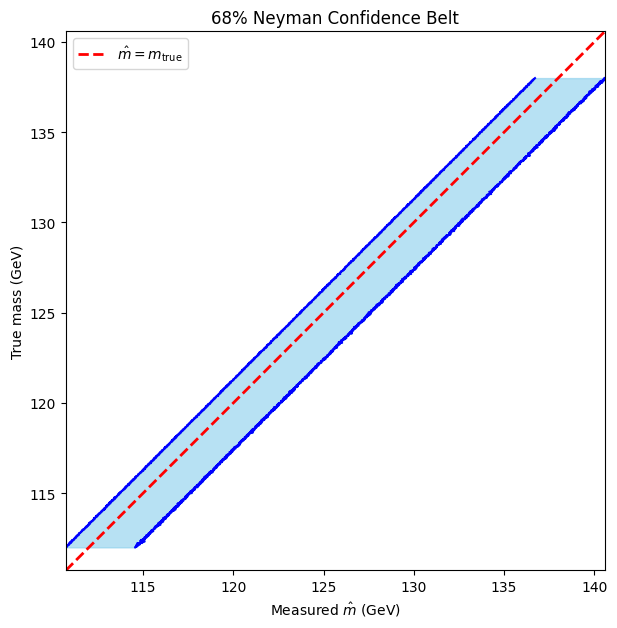

In [145]:
### plot Neyman belt


plt.figure(figsize=(7,7))

plt.fill_betweenx(trueMasses,
                  lower,
                  upper,
                  color='skyblue',
                  alpha=0.6)

plt.plot(lower, trueMasses, 'b')
plt.plot(upper, trueMasses, 'b')


### Convert to numpy arrays
lower_a = np.array(lower)
upper_a = np.array(upper)

# -----------------------------
# 45-degree line: measured = true
# -----------------------------
xmin = min(trueMasses.min(), lower_a.min())
xmax = max(trueMasses.max(), upper_a.max())

plt.plot([xmin, xmax],
         [xmin, xmax],
         'r--',
         linewidth=2,
         label=r'$\hat{m}=m_{\rm true}$')

plt.xlabel(r"Measured $\hat m$ (GeV)")
plt.ylabel(r"True mass (GeV)")
plt.title("68% Neyman Confidence Belt")
plt.legend()

# Make the axes have the same scale so the line appears at 45 degrees
plt.xlim(xmin, xmax)
plt.ylim(xmin, xmax)
plt.gca().set_aspect('equal', adjustable='box')

plt.show()

In [146]:
### invert the neyman belt

#print(lower)
#print(upper)
#print(trueMasses)
### invert the Neyman belt
mObserved = 124.1

inside = (lower <= mObserved) & (upper >= mObserved)


CI = trueMasses[inside]

print(CI.min(), CI.max())

121.48000000000485 125.40000000000686


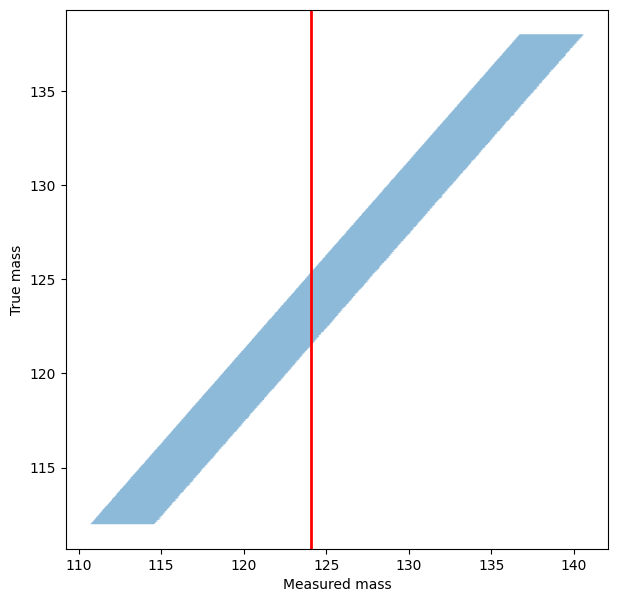

In [147]:
### plot
plt.figure(figsize=(7,7))

plt.fill_betweenx(trueMasses,
                  lower,
                  upper,
                  alpha=0.5)

plt.axvline(mObserved,
            color='red',
            lw=2)

plt.xlabel("Measured mass")

plt.ylabel("True mass")
plt.show()

In [148]:
### coverage test
### Full Neyman coverage test

Ncheck = 10000
covered = 0
skipped = 0

# The estimator is a single measurement: mhat = reco[0]
# The belt was also built from single measurements — consistent.
Nevent = 1

for i in range(Ncheck):

    # generate one measurement at the true mass
    reco = gaussian_response(m_true,
                             sigma_detector,
                             Nevent)

    if response=="cb":
        reco = crystalball_response(m_true,sigma_detector,1.5,3,Nevent)
        
    if response=="dcb":
        reco = cruijff_response(m_true,sigma_detector, sigma_detector*2, Nevent)
        
    mhat = reco[0]

    # invert Neyman belt using this observed mhat
    inside = (lower <= mhat) & (upper >= mhat)

    CI = trueMasses[inside]

    # with wide belt this should be rare
    # Count skips - if many, belt needs to be wider
    if CI.size == 0:
        skipped += 1
        continue
    
    CI_low = CI.min()
    CI_high = CI.max()

    if (CI_low <= m_true) and (m_true <= CI_high):
        covered += 1

n_valid = Ncheck - skipped
print(f"Skipped (mhat outside belt): {skipped} / {Ncheck}")
print(f"Coverage = {covered/n_valid:.4f}  (target 0.68)") 
print()
print("If skipped > 0: widen trueMasses further")
print("If coverage >> 0.68: check belt range or estimator consistency")

Skipped (mhat outside belt): 0 / 10000
Coverage = 0.6867  (target 0.68)

If skipped > 0: widen trueMasses further
If coverage >> 0.68: check belt range or estimator consistency
